## Import all the necessary config files

In [2]:
from config import *
from utils import *
import matplotlib.ticker as mticker
import matplotlib.pyplot as plt

## Run the coral model

In [3]:
# This runs the model once for the number of years selected in the user input files
run_coral_model(PSD_T0, MaxYear)

,Year,Branching_Area (%),Foliose_Area (%),Other_Area (%),total_coral_cover (%)
0,0,10.700000,2.000000,11.700000,24.400000
1,1,2.170029,0.657195,5.684280,8.511505
2,2,2.493007,0.655431,5.721606,8.870043
3,3,2.998729,0.666077,5.729362,9.394167
4,4,3.578107,0.686153,5.972943,10.237204
5,5,4.299878,0.718649,6.054094,11.072622
6,6,5.139518,0.761817,6.225704,12.127039
7,7,6.066680,0.820898,6.431753,13.319332
8,8,7.072402,0.878350,6.662513,14.613265
9,9,8.185498,0.944088,6.871478,16.001064


## Plot the change in total coral cover over the years

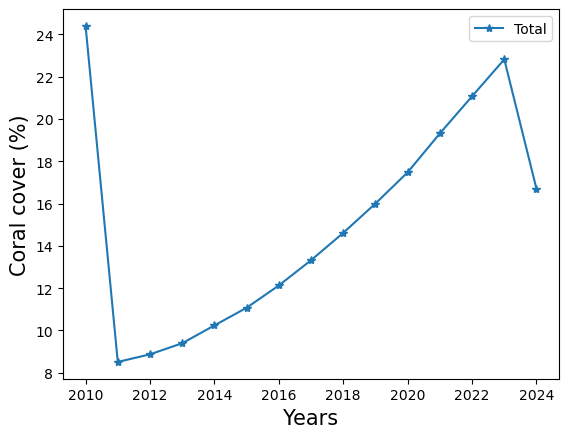

In [4]:
# Build actual years based on row count
n = len(opts.yearly_total_coral_cover_df)
actual_years = range(year_start, year_start + n)

# Plot with actual years as x-values
plt.plot(actual_years,
         opts.yearly_total_coral_cover_df['total_coral_cover (%)'],
         '-*',
         label='Total')

plt.xlabel('Years', fontsize=15)
plt.ylabel('Coral cover (%)', fontsize=15)
plt.legend()

# Make x-axis labels integers only
plt.gca().xaxis.set_major_formatter(mticker.FormatStrFormatter('%d'))

plt.show()

## The benthic cover over the years in percentage

In [5]:
opts.yearly_benthic_cover_df

,Year,total_benthic_cover (%),available_substrate (%),hard_substrate (%),dead_coral (%),CCA (%),turfing_algae (%),macro_algae (%),rubble (%),sediment (%),total_cc,unavailable_sub,tot
0,0,75.600000,60.400000,1.300000,1.300000,16.700000,41.100000,13.200000,1.000000,1.000000,24.400000,15.200000,100.000000
1,1,91.488495,66.630777,1.304904,6.049580,16.762992,42.764632,13.249790,10.352825,1.003772,8.511505,24.513921,99.656203
2,2,91.129957,67.961462,1.299624,7.469317,16.816059,42.591607,13.291735,8.654666,1.006950,8.870043,22.880917,99.712422
3,3,90.605833,68.854519,1.289784,8.617997,16.860796,42.269122,13.327096,7.231409,1.009629,9.394167,21.510906,99.759593
4,4,89.762796,69.199025,1.271790,9.504385,16.898612,41.679439,13.356987,6.039690,1.011893,10.237204,20.362899,99.799128
5,5,88.927378,69.357655,1.253901,10.211127,16.930553,41.093170,13.382233,5.042588,1.013806,11.072622,19.401954,99.832231
6,6,87.872961,69.134694,1.230707,10.723725,16.957584,40.333056,13.403599,4.208866,1.015424,12.127039,18.598196,99.859928
7,7,86.680668,68.637344,1.204268,11.078703,16.980487,39.466587,13.421702,3.512125,1.016796,13.319332,17.926411,99.883087
8,8,85.386735,67.923907,1.175500,11.302403,16.999910,38.523789,13.437055,2.930119,1.017959,14.613265,17.365269,99.902441
9,9,83.998936,67.020765,1.144623,11.412875,17.016398,37.511873,13.450087,2.444134,1.018946,16.001064,16.896779,99.918608


## Plot the benthic cover over the years for turfing algae, dead coral, rubble, macro algae and total coral cover in percentage

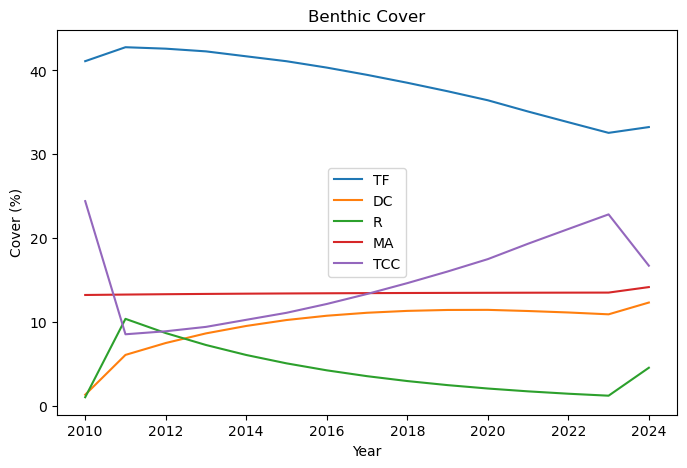

In [6]:
# Make a clean working copy and normalise column names
df = opts.yearly_benthic_cover_df.copy()
df.columns = df.columns.str.strip()

# Replace index with actual years
n = len(df)
actual_years = range(year_start, year_start + n)  # real years
df.index = pd.Index(actual_years, name="Year")

# Create a single plot
fig, ax = plt.subplots(figsize=(8, 5))

ax.plot(df['turfing_algae (%)'], label='TF')
ax.plot(df['dead_coral (%)'], label='DC')
ax.plot(df['rubble (%)'], label='R')
ax.plot(df['macro_algae (%)'], label='MA')
ax.plot(df['total_cc'], label='TCC')

ax.set_xlabel('Year')
ax.set_ylabel('Cover (%)')
ax.set_title('Benthic Cover')
ax.legend()

# Force integer year labels
ax.xaxis.set_major_formatter(mticker.FormatStrFormatter('%d'))

plt.show()

## Export the data frames to excel

In [7]:
# This function exports data frames to Excel 

export_to_excel(opts.yearly_population_df_list,'yearly_population')
export_to_excel(opts.yearly_surface_area_df_list,'yearly_surface_area')
export_to_excel(opts.yearly_total_coral_cover_df,'yearly_total_coral_cover')
export_to_excel(opts.yearly_benthic_cover_df,'yearly_benthic_cover')

## Plots

(1, 5, 8, 12)


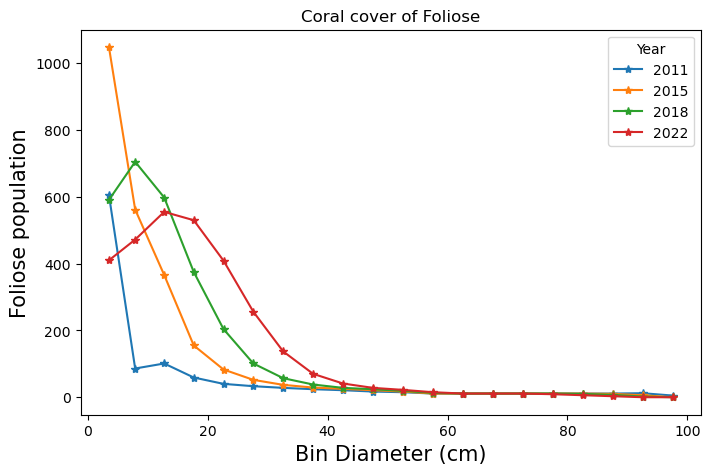

In [9]:
#Coral Cover Population

#Years you want to be plotted:
Years = 2011, 2015, 2018, 2022

# Check if any requested years are before the start year
if min(Years) < year_start:
    print(f"Error: Requested year {min(Years)} is before the start year {year_start}. Please use years from {year_start} onwards.")
elif max(Years) > year_end:
    print(f"Error: Requested year {max(Years)} is after the end year {year_end}. Please use years up to {year_end}.")
else:
    # Convert them to model years (indices) for the model
    model_years = tuple(year - year_start for year in Years)
    print(model_years)
    # Plot coral population change by type
    plot_coral_type_population_change('Foliose', False, *model_years)

(1, 5, 8, 12)


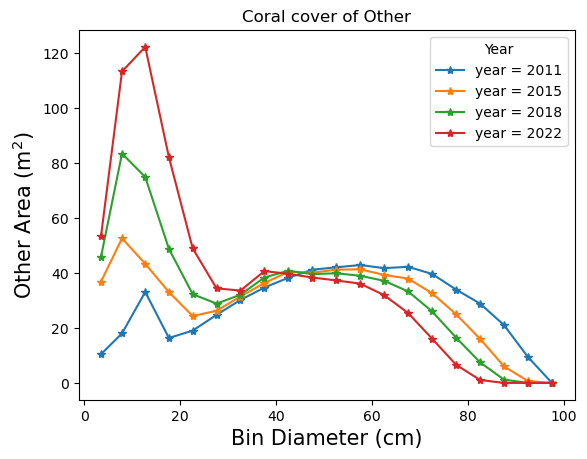

In [10]:
# This plots the Area of the coral type chosen for different input years
# Other

#Years you want to be plotted:
#Years you want to be plotted:
Years = 2011, 2015, 2018, 2022

# Check if any requested years are before the start year
if min(Years) < year_start:
    print(f"Error: Requested year {min(Years)} is before the start year {year_start}. Please use years from {year_start} onwards.")
elif max(Years) > year_end:
    print(f"Error: Requested year {max(Years)} is after the end year {year_end}. Please use years up to {year_end}.")
else:
    #Convert them to model years (indices) for the model)
    model_years = tuple(year - year_start for year in Years)

    print(model_years)

    #Plot coral area change by type
    plot_coral_type_areal_change('Other', False, *model_years)

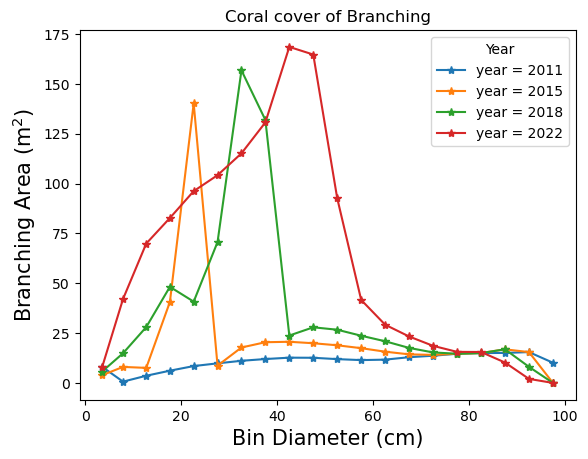

In [11]:
# This plots the Area of the coral type chosen for different input years
# Branching

#Years you want to be plotted:
#Years you want to be plotted:
Years = 2011, 2015, 2018, 2022

# Check if any requested years are before the start year
if min(Years) < year_start:
    print(f"Error: Requested year {min(Years)} is before the start year {year_start}. Please use years from {year_start} onwards.")
elif max(Years) > year_end:
    print(f"Error: Requested year {max(Years)} is after the end year {year_end}. Please use years up to {year_end}.")
else:
    #Convert them to model years (indices) for the model)
    model_years = tuple(year - year_start for year in Years)

    plot_coral_type_areal_change('Branching', False, *model_years)

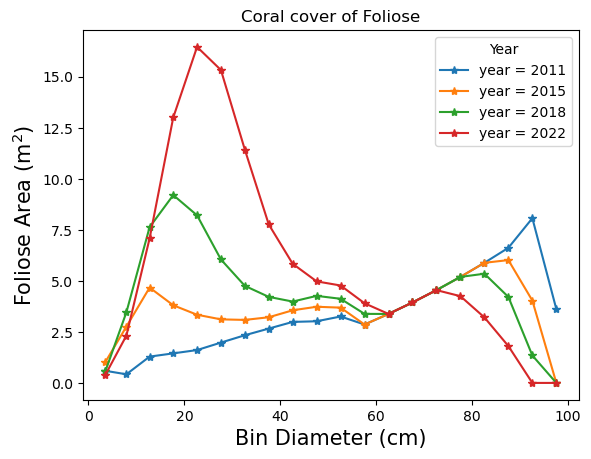

In [12]:
# This plots the Area of the coral type chosen for different input years
# Foliose

#Years you want to be plotted:
#Years you want to be plotted:
Years = 2011, 2015, 2018, 2022

# Check if any requested years are before the start year
if min(Years) < year_start:
    print(f"Error: Requested year {min(Years)} is before the start year {year_start}. Please use years from {year_start} onwards.")
elif max(Years) > year_end:
    print(f"Error: Requested year {max(Years)} is after the end year {year_end}. Please use years up to {year_end}.")
else:

    #Convert them to model years (indices) for the model)
    model_years = tuple(year - year_start for year in Years)

    plot_coral_type_areal_change('Foliose',False, *model_years)

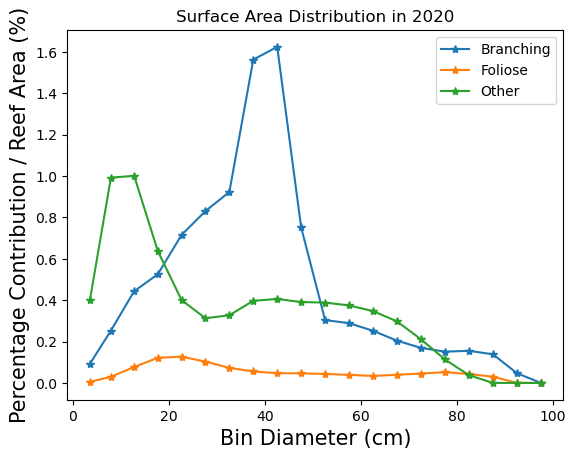

In [13]:
# Plot surface area distribution of different coral types in a given year.

Year = 2020

# Check if the year is within the valid range
if Year < year_start:
    print(f"Error: Requested year {Year} is before the start year {year_start}. Please use years from {year_start} onwards.")
elif Year > year_end:
    print(f"Error: Requested year {Year} is after the end year {year_end}. Please use years up to {year_end}.")
else:
    
    #Convert them to model years (indices) for the model)
    model_year = Year - year_start

    plot_surface_area_distribution(model_year)

In [14]:
# This function plots the percentage population distribution of the bins in a given year. 
# plot_population_distribution_in_percentage(year)
# For example: 100*branching_population_bin_2/total_branching_population 

Year = 2009
# Check if the year is within the valid range
if Year < year_start:
    print(f"Error: Requested year {Year} is before the start year {year_start}. Please use years from {year_start} onwards.")
elif Year > year_end:
    print(f"Error: Requested year {Year} is after the end year {year_end}. Please use years up to {year_end}.")
else:
    
    #Convert them to model years (indices) for the model)
    model_year = Year - year_start

    plot_population_distribution_in_percentage(model_year)

Error: Requested year 2009 is before the start year 2010. Please use years from 2010 onwards.


## Rugosity

In [15]:
# This function calculates the Rugosity and returns them in a list

rugosity_list = get_rugosity_list()
export_to_excel(rugosity_list,'Rugosity')

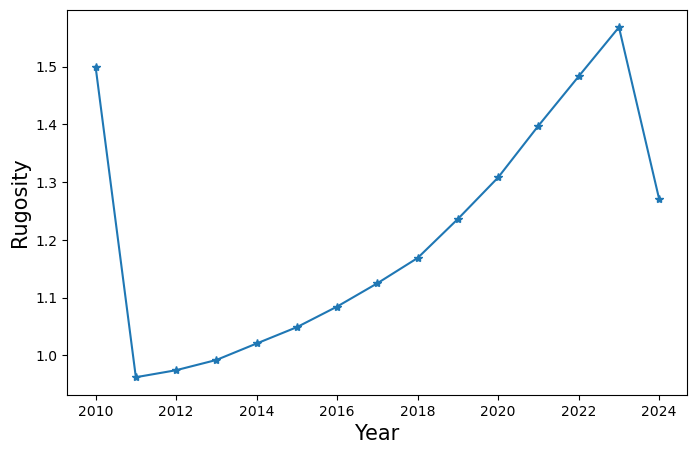

In [16]:
# This function plots the rugosity values over the years

plot_rugosity_year()

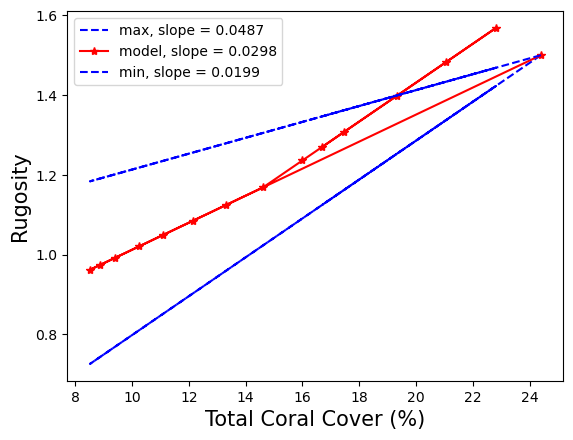

In [17]:
plot_rugosity_total_coral_cover()

## Run simulation for n number of times and plot the total coral cover

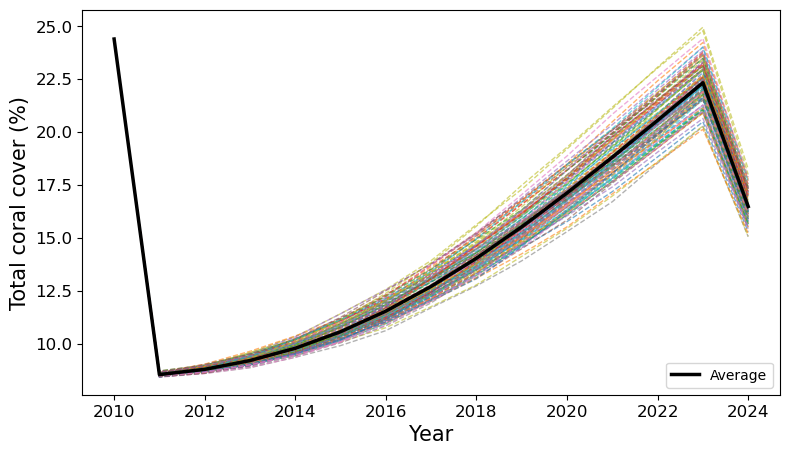

In [18]:
# run the model for n number of iterations (entered in the user inputs)
iteration_df, _ = run_multiple_model_iterations_total_cover(number_of_iterations)

plot_growth_rate_iterations(iteration_df)

In [19]:
iteration_df

,year,iteration_1,iteration_2,iteration_3,iteration_4,iteration_5,iteration_6,iteration_7,iteration_8,iteration_9,...,iteration_92,iteration_93,iteration_94,iteration_95,iteration_96,iteration_97,iteration_98,iteration_99,iteration_100,averaged
0,0,24.400000,24.400000,24.400000,24.400000,24.400000,24.400000,24.400000,24.400000,24.400000,...,24.400000,24.400000,24.400000,24.400000,24.400000,24.400000,24.400000,24.400000,24.400000,24.400000
1,1,8.441094,8.556135,8.618751,8.572766,8.596858,8.592764,8.554927,8.454612,8.486264,...,8.548782,8.498339,8.502944,8.489661,8.548310,8.472421,8.536902,8.509885,8.565599,8.535351
2,2,8.702475,8.808906,8.871860,8.905990,8.955134,8.895542,8.772140,8.591359,8.683719,...,8.730347,8.745166,8.761315,8.670436,8.846557,8.639876,8.780555,8.824068,8.841362,8.782873
3,3,9.133955,9.167698,9.288394,9.301657,9.335792,9.540330,9.177073,8.858584,9.081471,...,9.116313,9.141455,9.170270,8.969100,9.364499,8.999396,9.164821,9.308696,9.393391,9.198811
4,4,9.611683,9.719312,9.911843,9.997412,9.947303,10.180154,9.702514,9.353601,9.517268,...,9.725959,9.919579,9.787426,9.520705,10.200182,9.446347,9.772700,10.095233,10.202126,9.778420
5,5,10.357046,10.456035,10.830542,10.782722,10.765521,11.083392,10.358636,9.905628,10.073566,...,10.557587,10.776429,10.567562,10.408686,11.242808,10.072859,10.522166,11.110468,11.121159,10.561580
6,6,11.275657,11.392809,11.794265,11.754082,11.935362,12.015335,11.237732,10.613341,10.752356,...,11.590131,11.852709,11.697976,11.315712,12.499857,10.870264,11.582895,12.382892,12.116082,11.534352
7,7,12.235993,12.514073,12.921429,13.094561,13.059591,13.300826,12.410773,11.694873,11.749812,...,13.047427,13.082495,13.060308,12.323624,13.784680,12.026478,12.788324,13.820701,13.420913,12.704699
8,8,13.290203,14.102030,14.030147,14.308001,14.663718,14.705776,13.829085,12.730774,12.777633,...,14.602633,14.292656,14.611223,13.477580,15.241103,13.261752,14.113104,15.552827,14.961963,14.036726
9,9,14.532909,15.612056,15.494404,15.799659,16.262503,16.292093,15.343539,13.913702,14.125376,...,16.178544,15.644042,16.130184,14.694181,16.829659,14.743288,15.697684,17.486743,16.691782,15.518328


## Predicting the effect of a cyclone on the whole colony mortality

In [20]:
# This calculation does not use the existing cyclone data from the past, but rather predicts a hypothetical effect of a cyclone on the colony
# to it is possible to assess the effect even if no cyclone data exists for this location
# WCM_rates are the background whole colony mortality rates under no external stressor
# WCM_rates_during_cyclone is the calculated whole colony mortality rates during cyclone

cyclone = True
cyclone_severity_level = 1
distance_to_cyclone = 106

WCM_rates_during_cyclone = get_WCM_rates_after_cyclones(WCM_rates, cyclone_severity_level, distance_to_cyclone)
WCM_rates_during_cyclone

,Branching,Foliose,Other
0,0.211395,0.207152,0.204304
1,0.240056,0.099592,0.076628
2,0.317586,0.153189,0.111134
3,0.299933,0.192789,0.137641
4,0.337752,0.201401,0.137356
5,0.365026,0.222600,0.152280
6,0.385446,0.238793,0.163866
7,0.401236,0.251508,0.173081
8,0.413781,0.261733,0.180565
9,0.423972,0.270120,0.186756


## The effect of bleaching on the partial colony mortality

In [21]:
# PCM_rates are the background partial colony mortality rates under no external stressor
# PCM_rates_during_bleaching is the calculated partial colony mortality rates during bleaching event

branching_bleaching_rate = 34
foliose_bleaching_rate = 17
other_bleaching_rate = 17

dhw = 8

PCM_rates_during_bleaching = get_PCM_rates_after_dhw(PCM_rates, dhw, branching_bleaching_rate, foliose_bleaching_rate, other_bleaching_rate)
PCM_rates_during_bleaching

,Branching,Foliose,Other
0,0.044406,0.066606,0.066606
1,0.051468,0.076620,0.076620
2,0.059349,0.088200,0.088200
3,0.068226,0.101540,0.101540
4,0.078319,0.116976,0.116976
5,0.089897,0.134900,0.134900
6,0.103193,0.155758,0.155758
7,0.118788,0.180039,0.180039
8,0.137056,0.208263,0.208263
9,0.158541,0.240941,0.240941
